<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 52%, #2f7d73 100%);
    padding: 38px 34px 30px 34px;
    border-radius: 14px;
    margin: 8px 0 22px 0;
    box-shadow: 0 10px 28px rgba(16, 42, 67, 0.28);
    border: 1px solid rgba(255,255,255,0.16);
    text-align: center;
">
    <p style="color: rgba(255,255,255,0.72); margin: 0 0 10px 0; font-size: 12px; letter-spacing: 4px; text-transform: uppercase;">PHY-3202 · Notebook 02</p>
    <h1 style="color: white; margin: 0; font-size: 34px; font-weight: 400; letter-spacing: 1px;">Modèle de réseau, cascades et évolution</h1>
    <div style="width: 72px; height: 3px; background: #e7a23b; margin: 18px auto 14px auto; border-radius: 3px;"></div>
    <p style="color: rgba(255,255,255,0.92); margin: 0; font-size: 17px;">Du dispatch stationnaire aux séries temporelles</p>
</div>

<div style="
    background: #e8f0f2;
    color: #1f2933;
    border-left: 6px solid #1f4e5f;
    border-radius: 9px;
    padding: 16px 20px;
    margin: 0 0 18px 0;
">
<strong>Auteur :</strong> Alex Baker &nbsp; · &nbsp; <strong>Superviseur :</strong> Patrick Desrosiers &nbsp; · &nbsp; <strong>Idée original du projet :</strong> Nickie Menementis
</div>

## Fil directeur

Le notebook 01 construit et valide les outils d'analyse sans dépendre d'un réseau
électrique particulier. Le présent notebook construit le fil A au complet :
on part d'un réseau et d'un dispatch stationnaire, on introduit des avaries et
une cascade, puis on répète l'expérience sur plusieurs jours jusqu'à obtenir les
séries temporelles qui seront analysées par le fil B.

<div style="
    background: #eef7f4;
    color: #1f2933;
    border: 1px solid #c9ddda;
    border-radius: 9px;
    padding: 16px 20px;
    margin: 16px 0;
    text-align: center;
    font-size: 15px;
">
<code style="color: #1f2933; background: transparent;">Reseau</code>
&nbsp;→&nbsp;
<code style="color: #1f2933; background: transparent;">dispatch.resoudre()</code>
&nbsp;→&nbsp;
<code style="color: #1f2933; background: transparent;">cascade.journee()</code>
&nbsp;→&nbsp;
<code style="color: #1f2933; background: transparent;">evolution.simuler()</code>
&nbsp;→&nbsp;
<strong style="color: #1f2933;">séries temporelles</strong>
&nbsp;→&nbsp;
<em style="color: #1f2933;">fil B</em>
</div>

### Trois échelles à ne pas confondre

1. **Balayage en charge** : on fait varier $P_D/P_C$ pour comparer des états
   stationnaires. L'axe horizontal est un paramètre, pas le temps.
2. **Cascade d'une journée** : une demande et des avaries sont tirées, puis le
   dispatch est recalculé jusqu'à ce qu'aucune nouvelle ligne ne tombe. Les
   itérations décrivent une succession quasi-statique d'états, pas une dynamique
   électromécanique continue.
3. **Évolution lente** : on répète les journées. En mode `independant`, elles
   sont des réalisations Monte-Carlo sans mémoire; en mode `auto_organise`, la
   croissance de la demande et les renforcements créent au contraire une mémoire
   d'un jour au suivant.

<div style="
    background: var(--vscode-editor-inactiveSelectionBackground, rgba(231,162,59,0.12));
    border: 1px solid #e7a23b;
    border-radius: 9px;
    padding: 16px 20px;
    margin: 18px 0 6px 0;
    color: var(--vscode-editor-foreground, inherit);
">
<strong style="color: #1f4e5f;">Au programme</strong>
<ol style="margin: 10px 0 0 20px; padding: 0; line-height: 1.7;">
<li>Valider le dispatch sur un cas vérifiable à la main</li>
<li>Construire et calibrer le réseau réduit à 46 nœuds</li>
<li>Retrouver les deux transitions de charge</li>
<li>Observer la concentration spatiale des flux</li>
<li>Passer d'une avarie isolée à une cascade</li>
<li>Valider la chaîne complète dans le cas sans aléatoire</li>
<li>Produire un échantillon i.i.d. à charge fixée</li>
<li>Introduire la dynamique lente d'auto-organisation</li>
<li>Comparer les deux régimes avant toute analyse entropique temporelle</li>
<li>Exporter les séries vers le fil B</li>
</ol>
</div>

<div style="text-align: center; color: #52656d; font-size: 12px; margin-top: 18px;">
<strong>Question directrice :</strong> comment passe-t-on d'un état électrique stationnaire à des séries temporelles suffisamment contrôlées pour tester des mesures d'information ?
</div>


In [6]:
import numpy as np

from cascade_entropy import evolution, figures
from cascade_entropy.dispatch import demande_uniforme, resoudre
from cascade_entropy.entropie import entropie_repartition, nombre_effectif
from cascade_entropy.reseau import (
    Reseau,
    arbre,
    limites_par_niveau,
    matrice_de_flux,
)

figures.appliquer_style()

GRAINE = 20260915
P_C = 2623.9            # capacité totale de production, valeur publiée
CIBLE_SECONDE = 1.45    # niveau de charge visé pour la saturation des lignes

rng = np.random.default_rng(GRAINE)


<div style="
    background: #0f3345;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 34px 0 20px 0;
    border-left: 6px solid #e7a23b;
">
    <p style="color: #a9cbd7; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie I</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Construire l'état stationnaire</h2>
</div>

Avant de simuler une cascade, il faut savoir résoudre correctement l'état du
réseau avant et après chaque perturbation. Le dispatch est donc la brique
centrale : toutes les dynamiques ultérieures ne font que l'appeler de façon
répétée sous des conditions différentes.


<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 01 · Validation locale</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Le dispatch sur un cas vérifiable à la main</h2>
</div>

Étant donné une demande, le dispatch choisit la production des générateurs et la charge effectivement servie sous les contraintes du réseau. Dans la formulation utilisée ici, le problème est linéaire :

$$\min \left(\sum_i G_i - W\sum_j L_j\right)$$

avec contraintes de capacité de production, de demande maximale, d'équilibre global de puissance et de limites de transport. Le poids $W=100$ pénalise fortement le délestage : le solveur cherche donc d'abord à servir le plus de charge possible.

Avant de faire confiance au solveur sur un réseau de plusieurs dizaines de nœuds, on lui impose un problème dont la solution est évidente physiquement : une chaîne de trois nœuds, un générateur et deux charges.

<div style="background: #f8f4ea; color: #1f2933; border-left: 4px solid #e7a23b; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Principe de validation.</strong> Une brique numérique est beaucoup plus facile à croire lorsqu'elle reproduit d'abord un cas que l'on peut résoudre sans ordinateur.
</div>


In [7]:
chaine = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([10.0, 10.0]),
    reference=0,
)

solution = resoudre(chaine, demande=np.array([1.0, 1.0]),
                    puissance_max=np.array([10.0]))

print("Chaîne 0—1—2, générateur en 0, deux charges d'une unité")
print(f"  production      : {solution.production}")
print(f"  charge servie   : {solution.charge_servie}")
print(f"  flux            : {solution.flux}   (attendu [2, 1])")
print(f"  délestage       : {solution.delestage_total}")

Chaîne 0—1—2, générateur en 0, deux charges d'une unité
  production      : [2.]
  charge servie   : [1. 1.]
  flux            : [2. 1.]   (attendu [2, 1])
  délestage       : 0.0


Le générateur produit 2, la première ligne porte les deux charges, la seconde n'en porte qu'une. C'est le seul résultat physiquement possible, et le solveur le retrouve.

Pourquoi on peut vérifier ce résultat « à la main ». Dans une chaîne, il n'existe qu'un seul chemin entre le générateur et chaque charge — aucune boucle, aucun choix de routage possible. La charge en 2 ne peut recevoir sa puissance que par la ligne 1—2 : son flux vaut donc exactement 1. La charge en 1 est alimentée par la ligne 0—1, qui est aussi le seul passage vers tout ce qui est en aval : elle transporte donc la demande de la charge 1 plus tout ce qui continue vers la charge 2, soit $1 + 1 = 2$. Le générateur produit ce que la chaîne réclame au total. Aucune équation à résoudre — seulement suivre où l'énergie doit obligatoirement circuler.

C'est la règle générale documentée dans `reseau.py` : sur un arbre, le flux d'une ligne égale toujours la somme des injections du sous-arbre qu'elle alimente, indépendamment des réactances. Les réactances n'entreraient en jeu que s'il existait plusieurs chemins possibles entre lesquels répartir le courant — ce qui n'arrive jamais dans un arbre.


Maintenant, la même chose avec la ligne amont plafonnée à 1,5.

In [8]:
chaine_limitee = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([1.5, 10.0]),
    reference=0,
)

limitee = resoudre(chaine_limitee, demande=np.array([1.0, 1.0]),
                   puissance_max=np.array([10.0]))

print(f"  flux            : {limitee.flux}")
print(f"  charge servie   : {limitee.charge_servie}")
print(f"  délestage       : {limitee.delestage_total}   (attendu 0,5)")
print(f"  M_max           : {limitee.taux_maximal}")
print(f"  lignes saturées : {limitee.lignes_saturees}")

  flux            : [1.5 1. ]
  charge servie   : [0.5 1. ]
  délestage       : 0.5   (attendu 0,5)
  M_max           : 1.0
  lignes saturées : [0]


La ligne amont transporte exactement 1,5 sur une limite de 1,5 : son taux de charge vaut donc $M=1$. Elle est saturée, et non en dépassement.

Cette distinction est essentielle pour le reste du projet. Le dispatch impose les limites de transport comme des contraintes dures : une solution admissible ne contient jamais de ligne avec $M>1$. Dans le modèle de cascade, une ligne « surchargée » est donc opérationnellement une ligne collée à sa limite ($M$ proche de 1) qui peut ensuite tomber avec une probabilité $p_1$.

Le délestage de 0,5 n'est pas un artefact : il est précisément ce qui rend le problème de nouveau admissible lorsque la ligne ne peut plus transporter toute la demande.


<div style="
    background: linear-gradient(135deg, #2f7d73 0%, #4f9d8b 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(47,125,115,0.20);
">
    <p style="color: #e6f5f0; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 02 · Réseau réduit</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Le réseau à 46 nœuds et sa calibration</h2>
</div>

On passe maintenant au réseau en arbre utilisé pour les expériences du fil A :
46 nœuds, 45 lignes et 12 générateurs. Les capacités de ligne diminuent avec la
profondeur de l'arbre, puisqu'une branche proche de la racine doit écouler la
puissance de tout ce qui se trouve en aval.

Ce réseau est volontairement simple. Il permet de comprendre et de valider le
mécanisme sans ambiguïté topologique, mais il ne reproduit pas la redistribution
des flux d'un réseau maillé réel. Cette limite deviendra importante lorsque les
lignes commenceront à tomber.

<div style="background: #eef7f4; color: #1f2933; border-left: 4px solid #2f7d73; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Idée physique.</strong> Plus une ligne est proche de la racine, plus elle
agrège de puissance et plus sa capacité doit être grande.
</div>


In [9]:
reseau = arbre(4)
A = matrice_de_flux(reseau)
p_max = np.full(reseau.generateurs.size, P_C / reseau.generateurs.size)

# L'échelle des capacités est le seul paramètre libre : elle est fixée pour que
# la saturation apparaisse au niveau de charge rapporté dans la littérature.
base = limites_par_niveau(reseau)
facteur = resoudre(reseau, demande_uniforme(reseau, CIBLE_SECONDE * P_C),
                   limites=base, puissance_max=p_max, A=A).taux_maximal
limites = base * facteur

print(f"{reseau.n_noeuds} nœuds, {reseau.n_lignes} lignes, "
      f"{reseau.generateurs.size} générateurs")
print(f"capacités par niveau : {np.unique(limites).round(1)}")
print(f"facteur d'échelle appliqué aux valeurs publiées : {facteur:.4f}")

46 nœuds, 45 lignes, 12 générateurs
capacités par niveau : [111.9 231.3 470.  947.4]
facteur d'échelle appliqué aux valeurs publiées : 0.0607


Deux quantités servent ici de repères :

- `P_C = 2623.9` : capacité totale de production utilisée pour définir le rapport
  de charge $P_D/P_C$;
- `CIBLE_SECONDE = 1.45` : niveau de charge auquel on choisit de placer la
  saturation du transport pour cette reproduction réduite.

Les valeurs relatives retournées par `limites_par_niveau(reseau)` conservent la
hiérarchie des capacités entre niveaux de l'arbre. Leur échelle absolue est
ensuite ajustée par un facteur unique.

### Ce qui est calibré

On résout d'abord le dispatch à

$$\frac{P_D}{P_C}=1.45$$

avec les capacités de base. Le taux maximal obtenu, `facteur`, indique quelle
fraction de ces capacités serait utilisée par la ligne la plus sollicitée. En
multipliant toutes les limites par cette même valeur,

$$F_{\max,\ell}^{\,\mathrm{cal}} = \texttt{facteur}\, F_{\max,\ell}^{\,\mathrm{base}},$$

on conserve les rapports entre niveaux tout en imposant qu'une première ligne
atteigne $ M=1$ à la charge cible.

<div style="background: #fff6e8; color: #1f2933; border-left: 4px solid #e7a23b; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Important.</strong> La position exacte de la seconde transition est donc
<strong>calibrée</strong>; elle n'est pas prédite. En revanche, la première
transition à P_D/P_C=1, la loi de délestage au-delà de cette transition et
la façon dont la répartition des flux évolue sont des conséquences du modèle.
</div>


délestage   : 0.0
M_max       : 0.657
taux moyen  : 0.455


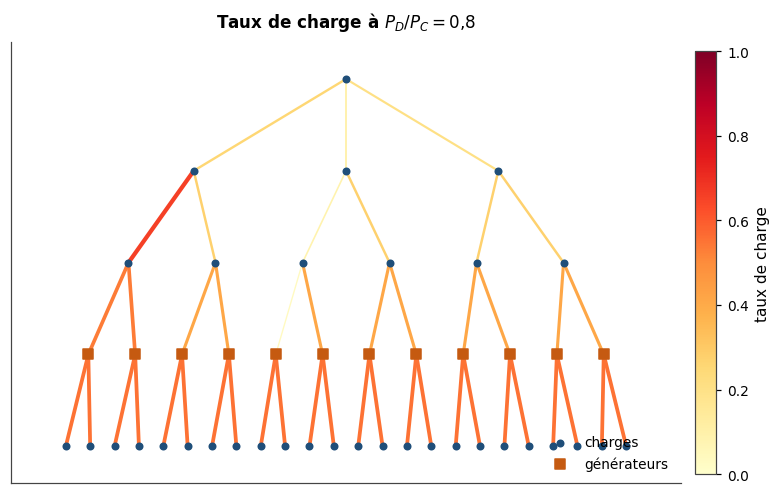

In [10]:
charge_moderee = resoudre(reseau, demande_uniforme(reseau, 0.8 * P_C),
                          limites=limites, puissance_max=p_max, A=A)

fig = figures.reseau_en_arbre(reseau, taux=charge_moderee.taux_de_charge,
                        titre="Taux de charge à $P_D/P_C = 0{,}8$")
figures.sauvegarder(fig, "reseau_taux_charge_moderee", sous_dossier="02_modele_et_evolution")

print(f"délestage   : {charge_moderee.delestage_total:.1f}")
print(f"M_max       : {charge_moderee.taux_maximal:.3f}")
print(f"taux moyen  : {charge_moderee.taux_de_charge.mean():.3f}")

<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(36,75,99,0.20);
">
    <p style="color: #dceef4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 03 · Balayage paramétrique</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Les deux transitions de charge</h2>
</div>

On augmente $P_D/P_C$ à profil de charge fixe et, pour chaque valeur, on résout
un nouvel état stationnaire. Il ne s'agit donc pas encore d'une évolution
temporelle.

On suit simultanément :

- la fraction de charge servie et le délestage;
- le taux de charge maximal $M_{\max}$;
- le taux moyen des lignes;
- le nombre de lignes saturées;
- le nombre effectif de lignes portant les flux.

<div style="background: #edf5f8; color: #1f2933; border-left: 4px solid #347b91; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Question d'observation.</strong> Que se passe-t-il après saturation de la production, lorsque la puissance totale servie ne peut plus augmenter mais que sa répartition spatiale peut encore changer ?
</div>


In [11]:
RATIOS = np.linspace(0.2, 2.0, 55)

colonnes = {cle: [] for cle in
            ("servie", "delestage", "taux_max", "taux_moyen", "saturees", "lignes_eff")}

for ratio in RATIOS:
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    colonnes["servie"].append(s.charge_servie.sum() / P_C)
    colonnes["delestage"].append(s.delestage_total / (ratio * P_C))
    colonnes["taux_max"].append(s.taux_maximal)
    colonnes["taux_moyen"].append(s.taux_de_charge.mean())
    colonnes["saturees"].append(s.lignes_saturees.size)
    colonnes["lignes_eff"].append(nombre_effectif(s.flux))

balayage = {cle: np.array(v) for cle, v in colonnes.items()}
seuils = {"production": 1.0, "transport": CIBLE_SECONDE}

WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/transition_puissance_servie.png')

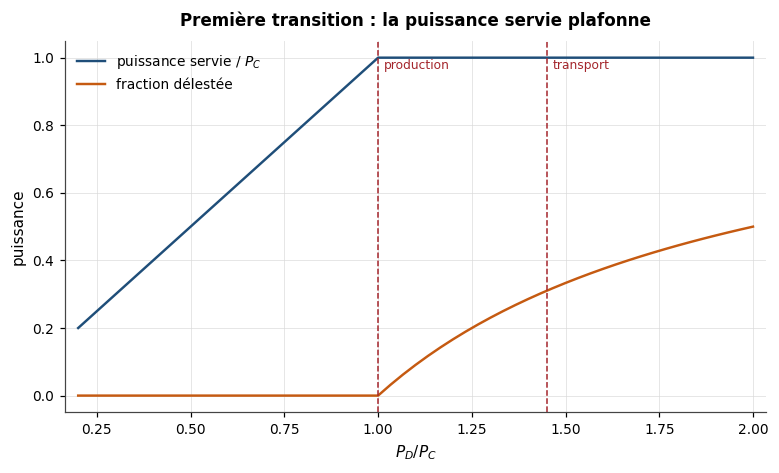

In [12]:
fig = figures.transitions(
    RATIOS,
    {"puissance servie / $P_C$": balayage["servie"],
     "fraction délestée": balayage["delestage"]},
    seuils, ylabel="puissance",
    titre="Première transition : la puissance servie plafonne",
)
figures.sauvegarder(fig, "transition_puissance_servie", sous_dossier="02_modele_et_evolution")

La première transition apparaît à

$$\frac{P_D}{P_C}=1.$$

À partir de ce point, la capacité totale de production est entièrement utilisée
et la puissance servie plafonne. Aucun paramètre n'a été réglé pour provoquer
cette transition : elle résulte directement de la contrainte de génération.

Si $r=P_D/P_C>1$, la puissance maximale pouvant être servie vaut $P_C$.
La fraction délestée attendue est donc

$$\frac{P_D-P_C}{P_D} = \frac{r-1}{r}.$$

On vérifie explicitement cette relation sur quelques points.


In [13]:
for ratio in (1.2, 1.5, 2.0):
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    mesure = s.delestage_total / (ratio * P_C)
    print(f"P_D/P_C = {ratio}  →  délesté {mesure:.4f}, attendu {(ratio-1)/ratio:.4f}")

P_D/P_C = 1.2  →  délesté 0.1667, attendu 0.1667
P_D/P_C = 1.5  →  délesté 0.3333, attendu 0.3333
P_D/P_C = 2.0  →  délesté 0.5000, attendu 0.5000


WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/transition_taux_charge.png')

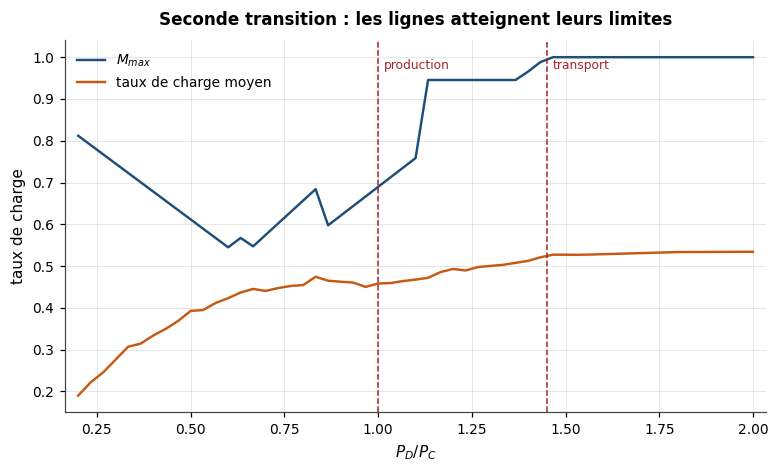

In [14]:
fig = figures.transitions(
    RATIOS,
    {"$M_{max}$": balayage["taux_max"],
     "taux de charge moyen": balayage["taux_moyen"]},
    seuils, ylabel="taux de charge",
    titre="Seconde transition : les lignes atteignent leurs limites",
)
figures.sauvegarder(fig, "transition_taux_charge", sous_dossier="02_modele_et_evolution")

Le second comportement est plus subtil. Une fois la production saturée, la **quantité totale** de puissance servie reste constante, mais $M_{\max}$ continue d'augmenter jusqu'à atteindre la limite du transport.

Il n'y a pas de contradiction : le délestage n'est pas nécessairement réparti uniformément entre toutes les charges. Lorsque les contraintes changent, le solveur peut modifier où la puissance est servie. La somme demeure la même, mais la géographie des injections change, donc les flux de lignes changent eux aussi.

Cette distinction entre **quantité totale** et **répartition spatiale** est centrale pour la suite : deux états peuvent transporter une puissance globale semblable tout en sollicitant le réseau de façons très différentes.

<div style="
    background: linear-gradient(135deg, #8b5e34 0%, #b47a3c 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f1c36b;
    box-shadow: 0 6px 18px rgba(139,94,52,0.20);
">
    <p style="color: #fff1d4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 04 · Observable spatiale</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Ce que voit l'entropie de répartition</h2>
</div>

On introduit ici une première mesure informationnelle, mais elle n'est pas temporelle. À un état donné, on considère la distribution de la puissance entre les lignes. Son entropie mesure le degré d'étalement de cette distribution, et son exponentielle fournit un nombre effectif de lignes.

Intuitivement :

- si les 45 lignes transportent des contributions comparables, le nombre effectif approche 45;
- si le flux se concentre sur un petit sous-ensemble, il diminue.

Cette observable complète donc $M_{\max}$ : le maximum décrit la ligne la plus sollicitée, tandis que l'entropie de répartition décrit la structure globale de la distribution des flux.

à P_D/P_C = 0,2 : 22.9 lignes effectives
au maximum      : 44.9
à P_D/P_C = 2,0 : 25.9 lignes effectives


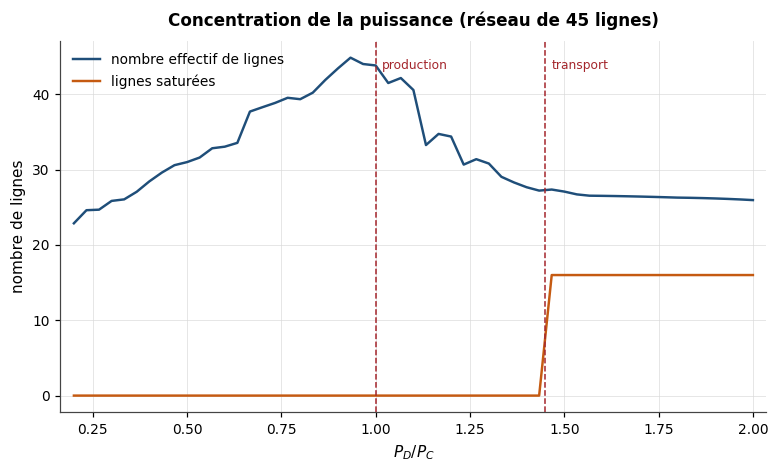

In [15]:
fig = figures.transitions(
    RATIOS,
    {"nombre effectif de lignes": balayage["lignes_eff"],
     "lignes saturées": balayage["saturees"]},
    seuils, ylabel="nombre de lignes",
    titre=f"Concentration de la puissance (réseau de {reseau.n_lignes} lignes)",
)
figures.sauvegarder(fig, "transition_concentration", sous_dossier="02_modele_et_evolution")

print(f"à P_D/P_C = 0,2 : {balayage['lignes_eff'][0]:.1f} lignes effectives")
print(f"au maximum      : {balayage['lignes_eff'].max():.1f}")
print(f"à P_D/P_C = 2,0 : {balayage['lignes_eff'][-1]:.1f} lignes effectives")

La courbe augmente d'abord jusqu'à une répartition presque uniforme, puis le
nombre effectif diminue lorsque le réseau se charge davantage : la puissance se
concentre sur un sous-ensemble plus restreint de lignes.

Ce résultat ne constitue pas encore un indicateur précurseur. Il montre seulement
qu'une observable informationnelle spatiale répond à l'état de stress du
réseau. Il faudra ensuite demander si elle apporte une information distincte de
$M_{\max}$, de la moyenne ou du délestage.


P_D/P_C = 0.5 : moyenne 0.393, max 0.612, entropie 0.988
P_D/P_C = 1.0 : moyenne 0.458, max 0.690, entropie 0.950
P_D/P_C = 1.5 : moyenne 0.527, max 1.000, entropie 0.875


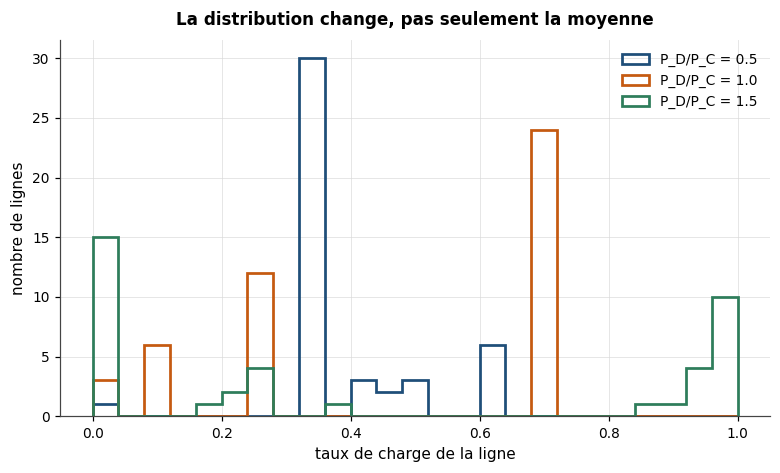

In [16]:
cas = {}
for ratio in (0.5, 1.0, 1.5):
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    cas[f"P_D/P_C = {ratio}"] = s.taux_de_charge

fig = figures.distributions_taux(cas, titre="La distribution change, pas seulement la moyenne")
figures.sauvegarder(fig, "distributions_taux_charge", sous_dossier="02_modele_et_evolution")

for nom, taux in cas.items():
    print(f"{nom} : moyenne {taux.mean():.3f}, max {taux.max():.3f}, "
          f"entropie {entropie_repartition(taux, normaliser=True):.3f}")

Deux états dont les moyennes sont voisines peuvent avoir des distributions de
taux de charge différentes; l'entropie de répartition est justement sensible à
cette différence.

Il faut toutefois garder une frontière conceptuelle nette :

- **entropie de répartition** : mesure spatiale calculée sur les lignes d'un seul
  état du réseau;
- **entropie de permutation / SampEn / MSE** : mesures calculées plus tard sur
  l'ordre temporel d'une série de plusieurs journées.

Le premier outil décrit *comment la puissance est répartie maintenant*; les
seconds chercheront à décrire *comment une observable évolue dans le temps*.


<div style="
    background: #442f48;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #f0b56b;
">
    <p style="color: #e6cfd7; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie II</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">De l'avarie isolée à la cascade</h2>
</div>

Le balayage précédent compare des états stationnaires intacts. Une cascade
commence lorsqu'un élément devient indisponible, que le dispatch est recalculé,
puis que ce nouvel état rend éventuellement d'autres lignes candidates à une
défaillance.


<div style="
    background: linear-gradient(135deg, #6b3f4f 0%, #9a5361 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f0b56b;
    box-shadow: 0 6px 18px rgba(107,63,79,0.20);
">
    <p style="color: #fbe7df; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 05 · Perturbation</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Faire tomber une ligne</h2>
</div>

Avant d'introduire toute la boucle probabiliste, on provoque manuellement une
seule avarie et on relance le dispatch. Dans l'implémentation, une ligne hors
service n'est pas supprimée du graphe : sa réactance est rendue très grande et
sa limite très petite. Cette représentation conserve une matrice exploitable
numériquement tout en la rendant pratiquement indisponible.

Cette cellule sert surtout à vérifier deux choses :

1. qu'un état perturbé peut être recalculé;
2. que les lignes hors service doivent être exclues des statistiques de charge.

<div style="background: #fbf0f1; color: #1f2933; border-left: 4px solid #9a5361; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Limite topologique.</strong> Un arbre ne possède qu'un chemin entre deux
nœuds. Une panne n'y crée donc pas la même redistribution de flux que dans un
réseau maillé.
</div>


ligne perdue : 3, reliant les nœuds [1 4]
délestage    : 0.0  →  0.0
M_max        : 0.657  →  0.569
lignes eff.  : 39.3  →  39.7


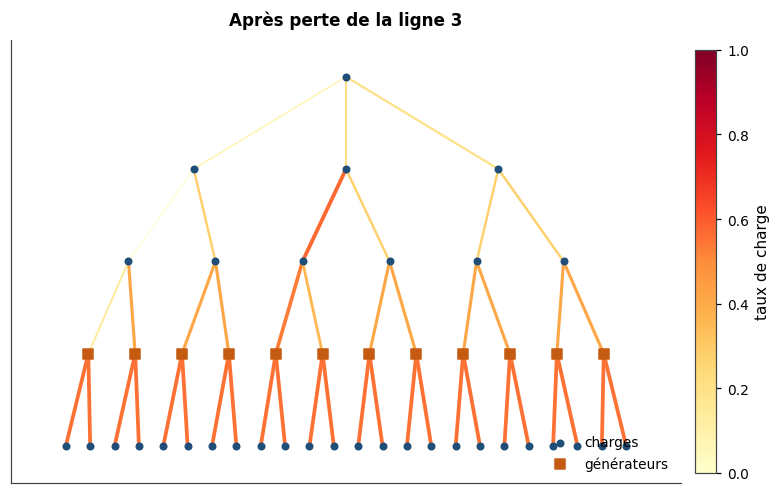

In [17]:
avant = resoudre(reseau, demande_uniforme(reseau, 0.8 * P_C),
                 limites=limites, puissance_max=p_max, A=A)

# On fait tomber la ligne la plus chargée. Une ligne en panne n'est pas retirée du
# réseau : sa réactance est rendue très grande et sa capacité très petite, ce qui
# évite de rendre la matrice singulière.
ligne_perdue = int(np.argmax(avant.taux_de_charge))

reseau_apres = Reseau(
    n_noeuds=reseau.n_noeuds, lignes=reseau.lignes,
    reactances=reseau.reactances.copy(), generateurs=reseau.generateurs,
    charges=reseau.charges, niveaux=reseau.niveaux, reference=reseau.reference,
)
reseau_apres.reactances[ligne_perdue] *= 1e6
limites_apres = limites.copy()
limites_apres[ligne_perdue] *= 1e-6

apres = resoudre(reseau_apres, demande_uniforme(reseau, 0.8 * P_C),
                 limites=limites_apres, puissance_max=p_max)

# La ligne hors service est exclue des statistiques : son taux de charge est le
# rapport de deux quantités quasi nulles et n'a aucun sens physique.
en_service = np.ones(reseau.n_lignes, dtype=bool)
en_service[ligne_perdue] = False

fig = figures.reseau_en_arbre(reseau, taux=np.where(en_service, apres.taux_de_charge, 0.0),
                        titre=f"Après perte de la ligne {ligne_perdue}")
figures.sauvegarder(fig, "reseau_apres_perte_ligne", sous_dossier="02_modele_et_evolution")

print(f"ligne perdue : {ligne_perdue}, reliant les nœuds {reseau.lignes[ligne_perdue]}")
print(f"délestage    : {avant.delestage_total:.1f}  →  {apres.delestage_total:.1f}")
print(f"M_max        : {avant.taux_maximal:.3f}  →  "
      f"{apres.taux_de_charge[en_service].max():.3f}")
print(f"lignes eff.  : {nombre_effectif(avant.flux):.1f}  →  "
      f"{nombre_effectif(apres.flux[en_service]):.1f}")

Pour une ligne rendue quasi inactive, le flux et la capacité deviennent tous deux très petits. Leur rapport peut alors rester artificiellement proche de 1, même si cette valeur n'a plus aucune signification physique.

Si cette ligne était conservée dans $M_{\max}$ ou dans la liste des candidates à une nouvelle panne, elle pourrait apparaître comme « saturée » alors qu'elle est déjà hors service. Le module `cascade` suit donc explicitement un masque des lignes indisponibles et les exclut des statistiques et des nouveaux tirages.

Limite connue du réseau en arbre, le chemin entre deux nœuds est unique. Lorsqu'une branche critique est perdue, il n'existe pas nécessairement de chemin alternatif permettant à la puissance de se redistribuer comme dans un réseau de transport maillé.

L'arbre demeure néanmoins très utile comme banc d'essai : ses flux sont faciles à interpréter et plusieurs erreurs de modélisation deviennent immédiatement visibles. Les conclusions portant spécifiquement sur la propagation par redistribution devront cependant être confrontées à un réseau maillé, par exemple l'IEEE 118-bus.

### Ce que `cascade.journee()` ajoute

La journée simulée assemble maintenant les briques précédentes dans un ordre
précis :

$$
\text{demande aléatoire}
\rightarrow
\text{avaries }p_0
\rightarrow
\text{dispatch}
\rightarrow
\text{lignes saturées}
\rightarrow
\text{avaries }p_1
\rightarrow
\text{redispatch}
\rightarrow \cdots
$$

- $g$ contrôle la fluctuation indépendante de la demande de chaque nœud;
- $p_0$ est la probabilité d'une avarie accidentelle avant le premier dispatch;
- $p_1$ est la probabilité qu'une ligne saturée et encore en service tombe
  pendant la cascade.

La boucle s'arrête lorsqu'aucune nouvelle ligne candidate ne tombe. Le délestage
du **dernier** dispatch devient alors la taille du blackout du jour.

Pour préparer l'analyse temporelle, le module conserve également l'état du
**premier** dispatch. Ainsi, le délestage décrit l'issue de la cascade, tandis que
$M_{\max}$ et le nombre effectif décrivent le réseau juste avant que les
défaillances par surcharge ne le déforment. Cette séparation évite de construire
un indicateur qui ne ferait que recopier mécaniquement la taille du blackout.


<div style="
    background: #173a52;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #e7a23b;
">
    <p style="color: #c7dce8; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie III</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">De la journée aux séries temporelles</h2>
</div>

`evolution.simuler()` répète `cascade.journee()` et transforme les résultats en
une observation par jour. Deux expériences sont conservées volontairement :

- `independant` : le réseau est fixe; chaque jour est un nouveau tirage Monte-Carlo;
- `auto_organise` : la demande croît et les réponses d'ingénierie modifient le
  système pour les jours suivants.

Le contraste entre les deux modes sera ensuite exploité par le fil B.


In [18]:
DEMANDE_INITIALE = 0.8 * P_C

# Paramètres de la journée de cascade.
# Ici, g = 0,9 correspond à la convention g = 1,9 utilisée par Carreras et al.
G = 0.9
P0 = 0.01
P1 = 1.0

print(f"réseau : {reseau.n_noeuds} nœuds, {reseau.n_lignes} lignes, "
      f"{reseau.generateurs.size} générateurs")
print(f"facteur d'échelle des limites : {facteur:.4f}")
print(f"demande moyenne de référence  : {DEMANDE_INITIALE:.1f}  "
      f"(P_D/P_C = {DEMANDE_INITIALE / P_C:.1f})")


réseau : 46 nœuds, 45 lignes, 12 générateurs
facteur d'échelle des limites : 0.0607
demande moyenne de référence  : 2099.1  (P_D/P_C = 0.8)


<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 06 · Validation intégrée</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Un jour sans surprise</h2>
</div>

Avant d'interpréter une simulation longue, on vérifie que l'empilement des
modules se réduit exactement au problème stationnaire lorsqu'on désactive tous
les mécanismes aléatoires.

On impose donc

$$g=p_0=p_1=0.$$

La demande ne fluctue pas, aucune avarie accidentelle ne peut se produire et
aucune ligne saturée ne peut tomber. Dans cette limite,
`evolution.simuler(..., 1 jour)` doit rendre le même état que
`dispatch.resoudre()` appelé directement.

<div style="background: #f8f4ea; color: #1f2933; border-left: 4px solid #e7a23b; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Test d'intégration.</strong> On ne valide plus une fonction isolée : on
vérifie que toute la chaîne <code style="color: #1f2933; background: transparent;">evolution → cascade → dispatch</code> respecte la limite analytique attendue.
</div>


In [19]:
parametres_nul = evolution.Parametres(
    mode="independant", demande_initiale=DEMANDE_INITIALE,
    puissance_max=p_max, g=0.0, p0=0.0, p1=0.0, limites=limites,
)
rng_nul = np.random.default_rng(GRAINE)
un_jour = evolution.simuler(reseau, 1, parametres_nul, rng_nul)[0]

demande_directe = demande_uniforme(reseau, DEMANDE_INITIALE)
solution_directe = resoudre(reseau, demande_directe, limites=limites, puissance_max=p_max)

print("Un jour, g = p0 = p1 = 0 : aucune avarie, aucune fluctuation.")
print(f"  délestage (journee) : {un_jour.delestage_total:.6f}")
print(f"  délestage (resoudre): {solution_directe.delestage_total:.6f}")
print(f"  M_max (journee)     : {un_jour.taux_maximal:.6f}")
print(f"  M_max (resoudre)    : {solution_directe.taux_maximal:.6f}")
print(f"  n_lignes_en_service : {un_jour.n_lignes_en_service} / {reseau.n_lignes}")

Un jour, g = p0 = p1 = 0 : aucune avarie, aucune fluctuation.
  délestage (journee) : 0.000000
  délestage (resoudre): 0.000000
  M_max (journee)     : 0.656804
  M_max (resoudre)    : 0.656804
  n_lignes_en_service : 45 / 45


Les deux chemins de calcul coïncident : même délestage, même $M_{\max}$, même nombre de lignes en service. Cela montre que l'enveloppe temporelle n'introduit pas d'effet caché lorsque ses mécanismes sont désactivés.

Ce test ne démontre évidemment pas que toute la simulation est physiquement parfaite; il vérifie une propriété beaucoup plus ciblée et indispensable :
**l'extension dynamique est compatible avec la brique stationnaire qu'elle encapsule**.


<div style="
    background: linear-gradient(135deg, #2f7d73 0%, #4f9d8b 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(47,125,115,0.20);
">
    <p style="color: #e6f5f0; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 07 · Contrôle Monte-Carlo</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Mode <code>independant</code> : un réseau fixe</h2>
</div>

Dans ce mode, la topologie, les limites de lignes et les capacités de génération ne changent jamais. Chaque journée recommence donc avec le même système; seuls les tirages de demande ($g$), d'avaries accidentelles ($p_0$) et de pannes par surcharge ($p_1$) varient.

Les journées sont ainsi conçues comme des réalisations **i.i.d.** d'une même expérience. Ce n'est pas encore une trajectoire physique d'un réseau qui vieillit : c'est un échantillon Monte-Carlo à charge moyenne fixée.

<div style="background: #eef7f4; color: #1f2933; border-left: 4px solid #2f7d73; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Rôle méthodologique.</strong> Ce mode fournit un contrôle négatif très utile pour le fil B : une méthode sensible à l'ordre temporel ne devrait pas inventer une structure lente là où les jours sont indépendants par construction.
</div>


In [20]:
N_JOURS_INDEP = 2000
parametres_indep = evolution.Parametres(
    mode="independant", demande_initiale=DEMANDE_INITIALE,
    puissance_max=p_max, g=G, p0=P0, p1=P1, limites=limites,
)
rng_indep = np.random.default_rng(GRAINE)
jours_indep = evolution.simuler(reseau, N_JOURS_INDEP, parametres_indep, rng_indep)
series_indep = evolution.series(jours_indep)

frac_delestage = float((series_indep["delestage_total"] > 1e-9).mean())
print(f"{N_JOURS_INDEP} jours simulés (mode independant)")
print(f"  jours avec délestage       : {frac_delestage:.1%}")
print(f"  délestage moyen            : {series_indep['delestage_total'].mean():.1f}")
print(f"  délestage maximal observé  : {series_indep['delestage_total'].max():.1f}")
print(f"  M_max moyen                : {series_indep['taux_maximal'].mean():.3f}")
print(f"  nombre effectif moyen      : {np.nanmean(series_indep['nombre_effectif']):.1f}"
      f"  (sur {reseau.n_lignes} lignes)")

2000 jours simulés (mode independant)
  jours avec délestage       : 82.1%
  délestage moyen            : 171.1
  délestage maximal observé  : 691.2
  M_max moyen                : 0.989
  nombre effectif moyen      : 35.4  (sur 45 lignes)


WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/apercu_independant.png')

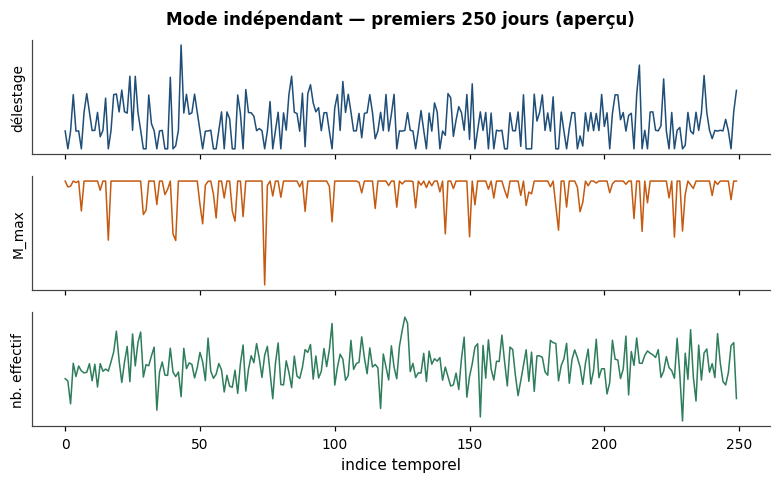

In [21]:
fig = figures.galerie_series(
    {
        "délestage": series_indep["delestage_total"],
        "M_max": series_indep["taux_maximal"],
        "nb. effectif": series_indep["nombre_effectif"],
    },
    n_points=250,
    titre="Mode indépendant — premiers 250 jours (aperçu)",
)
figures.sauvegarder(fig, "apercu_independant", sous_dossier="02_modele_et_evolution")

WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/distribution_delestage_independant.png')

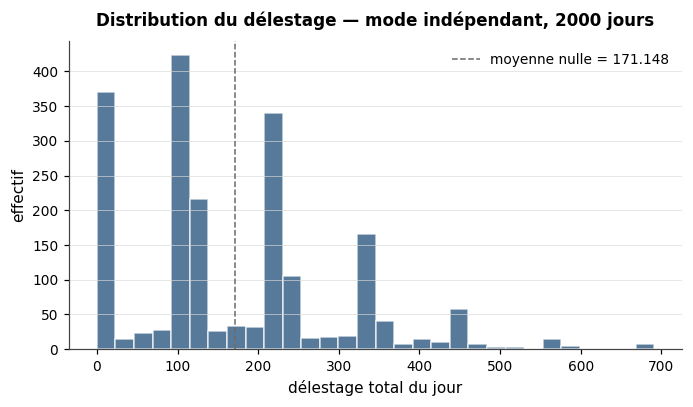

In [22]:
fig = figures.distribution_nulle(
    series_indep["delestage_total"],
    xlabel="délestage total du jour",
    titre=f"Distribution du délestage — mode indépendant, {N_JOURS_INDEP} jours",
)
figures.sauvegarder(fig, "distribution_delestage_independant", sous_dossier="02_modele_et_evolution")

Deux lectures différentes sont nécessaires.

**Aperçu temporel.** Les séries fluctuent sans dérive systématique : c'est le
comportement attendu d'un échantillon i.i.d. autour d'un régime fixe. L'axe des
jours sert ici seulement à ranger les réalisations; il ne porte pas de mémoire
physique entre deux points consécutifs.

**Distribution du délestage.** La distribution décrit au contraire la variété
des issues possibles d'une journée de cascade. Sa forme peut être structurée
même si l'ordre temporel est aléatoire : une distribution non triviale et une
dynamique temporelle non triviale sont deux questions distinctes.

Cette distinction sera importante pour l'entropie de permutation, qui dépend
précisément de l'ordre des observations.


<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(36,75,99,0.20);
">
    <p style="color: #dceef4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 08 · Mémoire du système</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Mode <code>auto_organise</code> : croissance et rétroaction</h2>
</div>

Le second mode introduit une véritable dépendance d'un jour au suivant. Trois mécanismes lents sont superposés aux cascades quotidiennes.

### 1. Croissance de la demande

`lambda_ = 1.018` représente un facteur annuel de croissance de 1,8 %. Le module
le convertit en facteur quotidien avant de faire dériver la demande moyenne.
La croissance est donc lente : elle agit sur des milliers de journées, pas sur
les itérations d'une cascade.

### 2. Mise à niveau de la génération

La marge moyenne est définie par

$$\frac{\Delta P}{\bar P_D} = \frac{\sum_j P_j^{\max}-\bar P_D}{\bar P_D}$$

Lorsqu'elle descend sous `marge_seuil`, des générateurs admissibles sont choisis et leur capacité augmente par petits incréments contrôlés par $k$, jusqu'à ce que la marge soit restaurée ou qu'aucun générateur ne puisse être amélioré ce jour-là.

### 3. Renforcement des lignes

Après une journée ayant produit un blackout, les lignes tombées par surcharge sont multipliées par $\mu$. Les pannes accidentelles $p_0$ ne déclenchent pas ce renforcement : un accident n'est pas interprété comme la preuve d'une capacité de transport insuffisante.

Les paramètres ci-dessous sont volontairement choisis pour que la rétroaction
devienne visible sur une simulation de 3000 jours. Il s'agit d'une démonstration
du mécanisme d'auto-organisation à échelle réduite, pas encore d'une
démonstration statistique de criticalité auto-organisée au sens asymptotique.

<div style="background: #edf5f8; color: #1f2933; border-left: 4px solid #347b91; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Point conceptuel.</strong> Contrairement au mode indépendant, l'état du
réseau au jour t+1 dépend maintenant de ce qui s'est produit au jour t.
C'est cette mémoire qui transforme une suite de réalisations en dynamique lente.
</div>


In [23]:
MARGE_INITIALE = 0.16
MARGE_SEUIL = 0.08
MU = 1.05       # dans [1,01 ; 1,10], Carreras et al. (2004)
K = 0.02        # « a few percent », valeur par défaut proposée
LAMBDA_ = 1.018  # 1,8 %/an

puissance_max_initiale = evolution.puissance_max_pour_marge(
    reseau, DEMANDE_INITIALE, MARGE_INITIALE
)
marge_verifiee = evolution.marge_moyenne(puissance_max_initiale, DEMANDE_INITIALE)
print(f"capacité initiale par générateur : {puissance_max_initiale[0]:.2f}")
print(f"capacité totale installée       : {puissance_max_initiale.sum():.1f}")
print(f"marge initiale visée            : {MARGE_INITIALE:.2%}")
print(f"marge initiale vérifiée         : {marge_verifiee:.2%}")
print(f"seuil de déclenchement          : {MARGE_SEUIL:.2%}")

capacité initiale par générateur : 202.91
capacité totale installée       : 2435.0
marge initiale visée            : 16.00%
marge initiale vérifiée         : 16.00%
seuil de déclenchement          : 8.00%


In [24]:
N_JOURS_AUTO = 3000
parametres_auto = evolution.Parametres(
    mode="auto_organise", demande_initiale=DEMANDE_INITIALE,
    puissance_max=puissance_max_initiale, g=G, p0=P0, p1=P1, limites=limites,
    lambda_=LAMBDA_, k=K, marge_seuil=MARGE_SEUIL, mu=MU,
)
rng_auto = np.random.default_rng(GRAINE)
jours_auto = evolution.simuler(reseau, N_JOURS_AUTO, parametres_auto, rng_auto)
series_auto = evolution.series(jours_auto)

jours_avec_maj = np.flatnonzero(series_auto["n_mises_a_niveau"] > 0)
premier_jour_maj = int(jours_avec_maj[0] + 1) if jours_avec_maj.size else None

print(f"{N_JOURS_AUTO} jours simulés (mode auto_organise)")
print(f"  premier jour avec mise à niveau : {premier_jour_maj}")
print(f"  nombre de mises à niveau        : {int(series_auto['n_mises_a_niveau'].sum())}")
print(f"  capacité installée : {puissance_max_initiale.sum():.1f} -> "
      f"{series_auto['capacite_totale_generateurs'][-1]:.1f}"
      f"  (+{series_auto['capacite_totale_generateurs'][-1] / puissance_max_initiale.sum() - 1:.1%})")
print(f"  marge moyenne       : {series_auto['marge_moyenne'][0]:.2%} -> "
      f"{series_auto['marge_moyenne'][-1]:.2%}")
print(f"  lignes renforcées (jours de blackout, cumulé) : "
      f"{int(series_auto['n_lignes_renforcees'].sum())}")

3000 jours simulés (mode auto_organise)
  premier jour avec mise à niveau : 1462
  nombre de mises à niveau        : 49
  capacité installée : 2435.0 -> 2626.1  (+7.8%)
  marge moyenne       : 15.99% -> 8.04%
  lignes renforcées (jours de blackout, cumulé) : 126


WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/apercu_auto_organise.png')

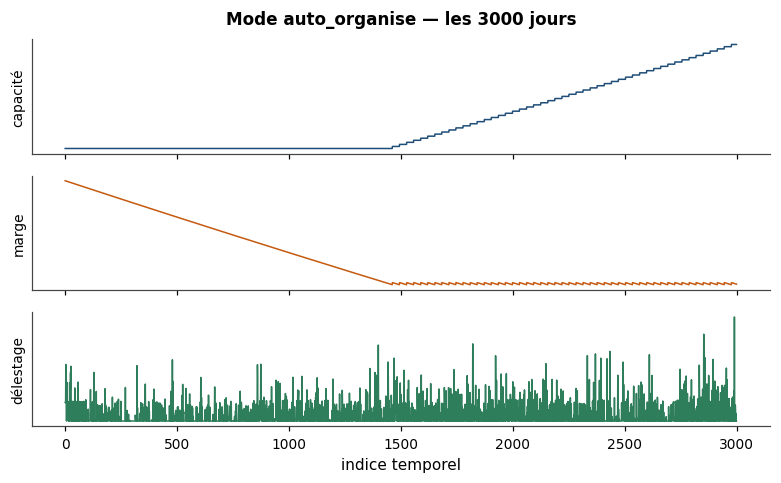

In [25]:
fig = figures.galerie_series(
    {
        "capacité": series_auto["capacite_totale_generateurs"],
        "marge": series_auto["marge_moyenne"],
        "délestage": series_auto["delestage_total"],
    },
    n_points=N_JOURS_AUTO,
    titre="Mode auto_organise — les 3000 jours",
)
figures.sauvegarder(fig, "apercu_auto_organise", sous_dossier="02_modele_et_evolution")

Le comportement obtenu suit le scénario attendu pour les paramètres choisis.
La marge reste d'abord proche de 16 % pendant le transitoire. À mesure que la
demande augmente, elle rejoint le seuil de 8 %; les mises à niveau commencent
alors et compensent progressivement la croissance. Sur cette réalisation, le
premier déclenchement apparaît au jour 1462 et la marge termine près du seuil.

Ce résultat valide surtout le **fonctionnement de la rétroaction** :
croissance → perte de marge → amélioration → restauration partielle de la marge.

Il ne faut pas encore l'interpréter comme une preuve de criticalité
auto-organisée. Pour cela, il faudra notamment étudier un régime stationnaire
beaucoup plus long, retirer le transitoire et examiner les distributions de
taille de blackout et leurs lois d'échelle.


<div style="
    background: linear-gradient(135deg, #8b5e34 0%, #b47a3c 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f1c36b;
    box-shadow: 0 6px 18px rgba(139,94,52,0.20);
">
    <p style="color: #fff1d4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 09 · Comparaison</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Les deux régimes, côte à côte</h2>
</div>

On compare maintenant les distributions produites par les deux protocoles avant
d'appliquer une mesure temporelle.

Cette comparaison doit être lue avec prudence : les modes ne diffèrent pas par
un seul paramètre. Le mode auto-organisé possède une capacité de génération qui
évolue, des limites de lignes qui peuvent être renforcées et une demande moyenne
qui dérive. Une différence observée entre les deux distributions ne peut donc
pas être attribuée à un mécanisme unique sans expérience de contrôle
supplémentaire.

<div style="background: #fbf5ec; color: #1f2933; border-left: 4px solid #b47a3c; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Question d'observation.</strong> Les deux protocoles produisent-ils déjà
des régimes statistiques différents avant que le fil B examine leur ordre
temporel ?
</div>


WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/comparaison_delestage.png')

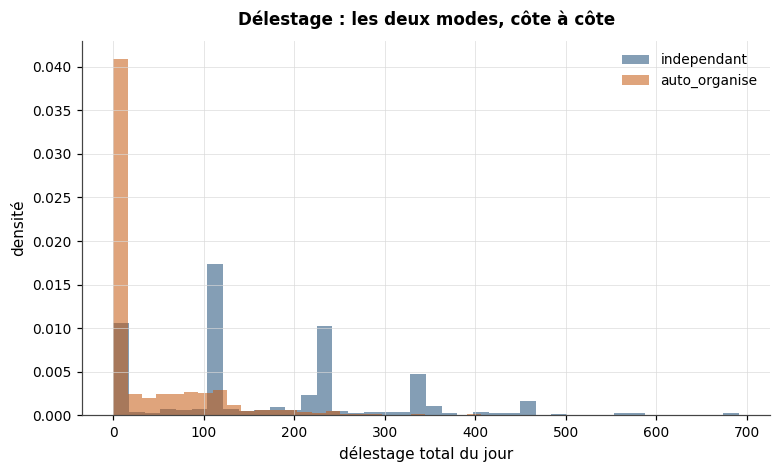

In [26]:
fig = figures.distributions_comparees(
    {"independant": series_indep["delestage_total"],
     "auto_organise": series_auto["delestage_total"]},
    xlabel="délestage total du jour",
    titre="Délestage : les deux modes, côte à côte",
)
figures.sauvegarder(fig, "comparaison_delestage", sous_dossier="02_modele_et_evolution")

WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/02_modele_et_evolution/comparaison_nombre_effectif.png')

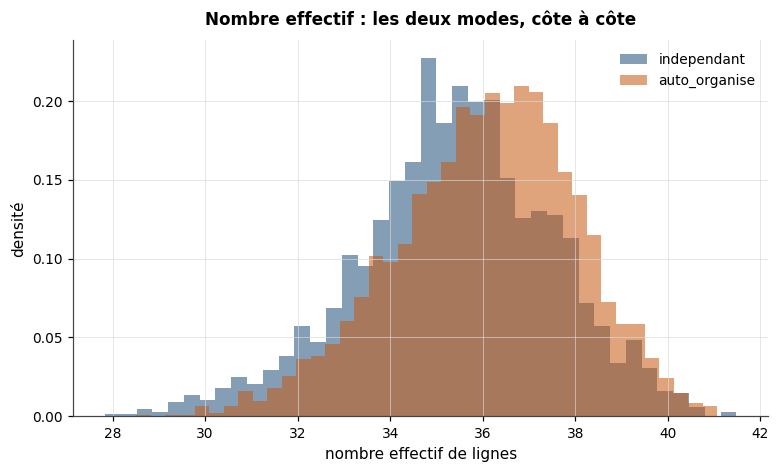

In [27]:
fig = figures.distributions_comparees(
    {"independant": series_indep["nombre_effectif"],
     "auto_organise": series_auto["nombre_effectif"]},
    xlabel="nombre effectif de lignes",
    titre="Nombre effectif : les deux modes, côte à côte",
)
figures.sauvegarder(fig, "comparaison_nombre_effectif", sous_dossier="02_modele_et_evolution")

Le délestage du mode `auto_organise` est davantage concentré près de zéro que
celui du mode `independant`, tandis que le nombre effectif de lignes change plus
modestement.

La tentation serait d'attribuer immédiatement cette différence au renforcement
sélectif des lignes par $\mu$. Ce mécanisme est effectivement un candidat
plausible, mais la comparaison actuelle ne l'isole pas : la capacité installée,
la marge et la demande évoluent également.

La prochaine expérience causale sera donc de modifier **un mécanisme à la fois**
(par exemple $\mu=1$, croissance sans renforcement, ou paramètres initiaux
appariés) pour identifier ce qui produit réellement l'écart observé.

Pour le fil B, l'intérêt principal est déjà acquis : on dispose maintenant de
deux familles de séries ayant des propriétés temporelles volontairement
différentes — une suite i.i.d. sans mémoire et une dynamique lente avec
rétroaction.


<div style="
    background: #2f3d43;
    padding: 14px 22px;
    border-radius: 10px;
    margin: 36px 0 20px 0;
    border-left: 6px solid #d6b26e;
">
    <p style="color: #d7e0e3; margin: 0 0 4px 0; font-size: 11px; letter-spacing: 3px; text-transform: uppercase;">Partie IV</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Passage du fil A au fil B</h2>
</div>

Le rôle de ce notebook s'arrête lorsque les séries sont générées de façon
reproductible. Les fichiers `.npz` constituent l'interface entre le modèle
électrique et l'analyse informationnelle : le notebook suivant peut donc charger
les observables sans reconstruire ni rerouler tout le fil A.


In [28]:
from cascade_entropy.chemins import DOSSIER_DATA

# DOSSIER_DATA pointe toujours vers <racine_du_depot>/data, peu importe le
# répertoire de travail du noyau Jupyter (notebooks/ ou la racine).
dossier = DOSSIER_DATA
chemin_indep = dossier / "evolution_independant.npz"
chemin_auto = dossier / "evolution_auto_organise.npz"
evolution.ecrire(series_indep, chemin_indep)
evolution.ecrire(series_auto, chemin_auto)

print(f"écrit : {chemin_indep}")
print(f"écrit : {chemin_auto}")
print(f"clés disponibles : {list(series_auto.keys())}")

écrit : c:\Users\alexb\Documents\Projets\cascade-entropy\data\evolution_independant.npz
écrit : c:\Users\alexb\Documents\Projets\cascade-entropy\data\evolution_auto_organise.npz
clés disponibles : ['jour', 'delestage_total', 'taux_maximal', 'nombre_effectif', 'n_lignes_en_service', 'capacite_totale_generateurs', 'marge_moyenne', 'n_mises_a_niveau', 'n_lignes_renforcees']


<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 100%);
    padding: 22px 26px;
    border-radius: 10px;
    margin: 34px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(16,42,67,0.22);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Bilan · Fil A</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Ce qui est établi — et ce qui ne l'est pas encore</h2>
</div>

<div style="background: #f3f7f6; color: #1f2933; border: 1px solid #c9ddda; border-radius: 9px; padding: 16px 20px;">
<p><strong>Validé numériquement</strong> — le dispatch retrouve des cas calculables
à la main; la chaîne <code style="color: #1f2933; background: transparent;">evolution → cascade → dispatch</code> se réduit au
dispatch seul lorsque <em>g = p₀ = p₁ = 0</em>.</p>

<p><strong>Reproduit par construction physique</strong> — la saturation de la
production apparaît à P_D/P_C=1, le délestage suit
(r-1)/r au-delà, et la répartition des flux continue d'évoluer même lorsque
la puissance totale servie plafonne.</p>

<p><strong>Calibré explicitement</strong> — l'échelle des limites de transport est
choisie pour placer la seconde transition à la charge cible; la marge initiale
et son seuil sont choisis pour rendre la rétroaction visible sur 3000 jours.</p>

<p><strong>Démontré à échelle réduite</strong> — le mécanisme de dynamique lente
fonctionne : croissance de la demande, perte de marge, mises à niveau de la
génération et renforcement de lignes produisent un système avec mémoire.</p>

<p><strong>Pas encore démontré</strong> — la criticalité auto-organisée au sens
statistique, la robustesse sur un réseau maillé réaliste et l'origine causale des
différences entre les deux modes nécessitent encore des contrôles dédiés.</p>

<p style="margin-bottom: 0;"><strong>Passage au fil B</strong> — les séries
<code style="color: #1f2933; background: transparent;">delestage_total</code>, <code style="color: #1f2933; background: transparent;">taux_maximal</code> et
<code style="color: #1f2933; background: transparent;">nombre_effectif</code> peuvent maintenant être analysées par entropie de
permutation, SampEn/MSE et contrôles de substitution sans mélanger la
construction du modèle avec son analyse.</p>
</div>

<div style="text-align: center; color: #52656d; font-size: 12px; margin-top: 16px;">
<strong>Le fil A ne cherche pas encore le précurseur :</strong> il construit les expériences contrôlées dans lesquelles le fil B pourra chercher s'il existe.
</div>
